In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np

from scipy.spatial import ConvexHull
from scipy import stats

In [61]:
df = pd.read_csv('data/convextutorial.csv')
df

,eventId,minute,second,teamId,x,y,playerId,type/displayName,type/value
0,2,0,0.0,65,0.0,0.0,NaN,Start,32
1,2,0,0.0,833,0.0,0.0,NaN,Start,32
2,3,0,1.0,833,50.8,51.5,303800.0,Pass,1
3,4,0,4.0,833,28.4,58.4,316957.0,Pass,1
4,5,0,7.0,833,66.6,24.7,303800.0,BallTouch,61
...,...,...,...,...,...,...,...,...,...
1576,1018,92,7.0,65,0.0,0.0,NaN,End,30
1577,1019,0,0.0,65,0.0,0.0,NaN,End,30
1578,676,0,0.0,833,0.0,0.0,NaN,End,30
1579,1,0,0.0,65,0.0,0.0,NaN,FormationSet,34


In [62]:
#Preencher dados faltantes e ajustar a escala do campo
df = df.fillna(0)
df['y'] = .8*df['y']
df['x'] = 1.2*df['x']

In [63]:
#Selecionar apenas as ações do Barcelona
df = df[df['teamId'] == 65]
df

,eventId,minute,second,teamId,x,y,playerId,type/displayName,type/value
0,2,0,0.0,65,0.00,0.00,0.0,Start,32
5,3,0,8.0,65,33.48,64.48,5.0,BallRecovery,49
6,4,0,9.0,65,36.72,51.44,5.0,Pass,1
7,5,0,13.0,65,31.68,17.92,28.0,Pass,1
8,6,0,18.0,65,35.04,30.16,4.0,Pass,1
...,...,...,...,...,...,...,...,...,...
1569,1016,92,3.0,65,110.64,50.40,17.0,Dispossessed,50
1574,1017,92,6.0,65,90.72,66.80,5.0,Interception,8
1576,1018,92,7.0,65,0.00,0.00,0.0,End,30
1577,1019,0,0.0,65,0.00,0.00,0.0,End,30


In [64]:
df['playerId'] = df['playerId'].astype('int')

In [65]:
#Selecionar jogadores únicos
players = df.playerId.unique()
players

array([ 0,  5, 28,  4, 23,  7, 11, 21,  1,  9, 18, 16, 17, 12])

In [66]:
#Selecionando os titulares do Barcelona
starters = players[1: 12]

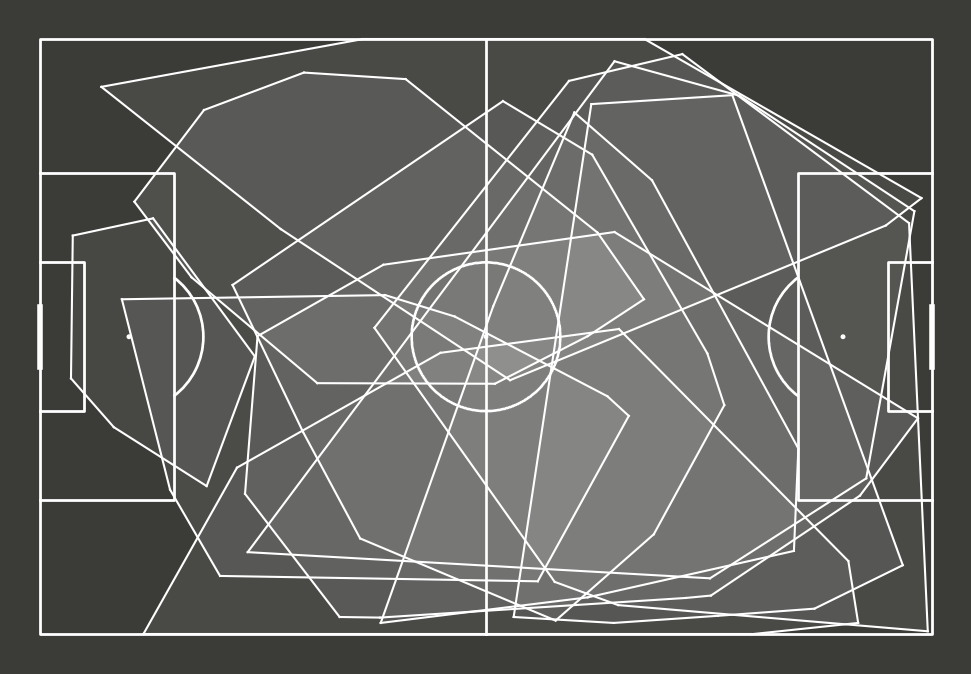

In [72]:
#Plotando um jogador
fig, ax = plt.subplots(figsize=(13, 8.5))
fig.set_facecolor('#3b3b38')
ax.patch.set_facecolor('#3b3b38')
pitch = Pitch(pitch_type='statsbomb', pitch_color='#3b3b38', line_color='white')
pitch.draw(ax=ax, constrained_layout=True, tight_layout=False, figsize=(16, 11))
plt.gca().invert_yaxis()

#df1 = df[df['playerId'] == 21]
#df1 = df1[df1['type/value'] == 1]

#Aparar o espaço coberto pelo jogador
#df1 = df1[np.abs(stats.zscore(df1[['x', 'y']]) < 2)]

#points = df1[['x', 'y']].values

#hull = ConvexHull(df1[['x', 'y']])

#plt.scatter(df1['x'], df1['y'])

#for i in hull.simplices:
#    plt.plot(points[i, 0], points[i, 1], 'white')
#    plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], 'white', alpha=.01)


#Plotar todos os titulares
for player in starters:
    df2 = df[df['playerId'] == player]
    df2 = df2[df2['type/value'] == 1]

    df2 = df2[np.abs(stats.zscore(df2[['x', 'y']]) < .5)]

    points = df2[['x', 'y']].values

    try:
        hull = ConvexHull(df2[['x', 'y']])
    except:
        pass
    
    try:
        for k in hull.simplices:
            plt.plot(points[k, 0], points[k, 1], 'white')
            plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], 'white', alpha=.01) 
    except:
        pass 